# ICMS 150 (2 Day experiment summary)

- Closed loop plan: day 1: perform visual (16 orientations, 100 trials) and electrical (3000 patterns, 50 oracles x 20 trials). This notebook is used after output spike sorting and curation to fit stimulus-encoder TCN model and generate stimualtion patterns for each orientation to try on day 2. 


Visual stim duration: 0.5s ON, 0.5s OFF
Velocity(temporal frequency): 3Hz
Width (spatial frequency): 0.05 cycle/degree
After that is 4000 patterns, 3000 samples appear 1 times, 50 oracle samples repeating 20 times


In [1]:
import sys
sys.path.insert(0, '../patterns_5k')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import read_pattern_json, preprocess_pattern_stimulations_df, build_pattern_stims_nominal
%load_ext autoreload
%autoreload 2
day1_datadir = "data/icms_150_6_2_26"
day2_datadir = "data/icms_150_6_3_26"
mode = "pca"

all_spikes_day1 = np.load(f"{day1_datadir}/All_Shank_Spk_Vecs.npy", allow_pickle=False) # contains each spike indexed with (sample index, unit index, segment index)
all_spikes_day2 = np.load(f"{day2_datadir}/All_Shank_Spk_Vecs.npy", allow_pickle=False) # contains each spike indexed with (sample index, unit index, segment index)

spikes_df_day1 = pd.DataFrame(all_spikes_day1)  # columns auto-named from dtype fields
spikes_df_day1.rename(columns={'sample_index': 'timestamp', 'unit_index': 'neuron_id'}, inplace=True)
spikes_df_day1.drop(columns=['segment_index'], inplace=True)

spikes_df_day2 = pd.DataFrame(all_spikes_day2)  # columns auto-named from dtype fields
spikes_df_day2.rename(columns={'sample_index': 'timestamp', 'unit_index': 'neuron_id'}, inplace=True)
spikes_df_day2.drop(columns=['segment_index'], inplace=True)

pattern_df_day1, min_pattern_timestamp_day1 = preprocess_pattern_stimulations_df(read_pattern_json(f"{day1_datadir}/Combined_Pattern_Registrations.pkl"), align_to_stim=True)
pattern_df_day2, min_pattern_timestamp_day2 = preprocess_pattern_stimulations_df(read_pattern_json(f"{day2_datadir}/Combined_Pattern_Registrations.pkl"), align_to_stim=True)

visual_stim_times_day1= np.load(f"{day1_datadir}/VStim_Onset_TS.npy") * 30 # 1600
visual_stim_times_day2= np.load(f"{day2_datadir}/VStim_Onset_TS.npy") * 30 # 1600
visual_stim_labels_day1 = np.load(f"{day1_datadir}/VStim_Labels.npy") # 1600 
visual_stim_labels_day2 = np.load(f"{day2_datadir}/VStim_Labels.npy") # 1600

visual_orientation_degs1 = np.sort(np.unique(visual_stim_labels_day1))
visual_orientation_degs2 = np.sort(np.unique(visual_stim_labels_day2))
visual_trial_df1 = pd.DataFrame({
    'timestamp': visual_stim_times_day1,
    'orientation': visual_stim_labels_day1
})
visual_trial_df2 = pd.DataFrame({
    'timestamp': visual_stim_times_day2,
    'orientation': visual_stim_labels_day2
})
min_visual_timestamp_1 = visual_trial_df1['timestamp'].min()
max_visual_timestamp_1 = visual_trial_df1['timestamp'].max()
min_visual_timestamp_2 = visual_trial_df2['timestamp'].min()
max_visual_timestamp_2 = visual_trial_df2['timestamp'].max()

visual_spikes_1 = spikes_df_day1[(spikes_df_day1['timestamp'] >= min_visual_timestamp_1) & (spikes_df_day1['timestamp'] <= max_visual_timestamp_1)].copy()
visual_spikes_2 = spikes_df_day2[(spikes_df_day2['timestamp'] >= min_visual_timestamp_2) & (spikes_df_day2['timestamp'] <= max_visual_timestamp_2)].copy()

## Visual Tuning over 2 Days 

In [2]:

# --- Timing constants -------------------------------------------------
# Spike timestamps are in *samples* at SAMPLE_RATE Hz. The visual stimulus
# was shown for STIM_MS ms, so we bin the full stim window (no data is
# thrown away). The window is chopped into bins of BIN_MS ms.
SAMPLE_RATE    = 30_000                       # Hz
STIM_MS        = 500                          # stimulus duration (ms)
BIN_MS         = 10                           # PSTH bin width (ms)

SAMPLES_PER_MS = SAMPLE_RATE // 1000          # 30 samples / ms
WINDOW_LEN     = STIM_MS * SAMPLES_PER_MS     # 500 ms -> 15000 samples
BIN_SAMPLES    = BIN_MS  * SAMPLES_PER_MS     # 50 ms  -> 1500 samples
N_BINS         = WINDOW_LEN // BIN_SAMPLES    # STIM_MS / BIN_MS
assert WINDOW_LEN % BIN_SAMPLES == 0, "BIN_MS must evenly divide STIM_MS"

N_VIS_TRIALS = 100

def make_avg_binned_responses(visual_spikes, visual_trial_df, visual_orientation_degs):
    all_neuron_ids = np.sort(visual_spikes['neuron_id'].unique())
    n_neurons = len(all_neuron_ids)
    neuron_to_idx = {n: i for i, n in enumerate(all_neuron_ids)}

    sum_responses = []
    trial_labels = []
    for orientation in visual_orientation_degs:
        sum_response = np.zeros((n_neurons, N_BINS))
        for trial in range(N_VIS_TRIALS):
            trial_time = visual_trial_df[visual_trial_df['orientation'] == orientation].iloc[trial]['timestamp']
            trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= trial_time) &
                                        (visual_spikes['timestamp'] <  trial_time + WINDOW_LEN)]
            if trial_spikes.empty:
                continue
            bin_edges = trial_time + np.arange(N_BINS + 1) * BIN_SAMPLES  # N_BINS+1 edges across STIM_MS

            for neuron_id in trial_spikes['neuron_id'].unique():
                idx = neuron_to_idx[neuron_id]
                counts, _ = np.histogram(
                    trial_spikes[trial_spikes['neuron_id'] == neuron_id]['timestamp'],
                    bins=bin_edges,
                )
                sum_response[idx] += counts
        sum_response /= N_VIS_TRIALS  # average over trials 
        sum_responses.append(sum_response) 
    sum_responses = np.array(sum_responses)
    return sum_responses  # (n_orientations, n_neurons, N_BINS)
avg_vis_responses_1 = make_avg_binned_responses(visual_spikes_1, visual_trial_df1, visual_orientation_degs1)
avg_vis_responses_2 = make_avg_binned_responses(visual_spikes_2, visual_trial_df2, visual_orientation_degs2)
print(f"Window: {STIM_MS} ms = {WINDOW_LEN} samples at {SAMPLE_RATE} Hz")
print(f"Bins:   {N_BINS} x {BIN_MS} ms ({BIN_SAMPLES} samples each)")
print(f"avg_vis_responses1 shape (orient, neuron, time_bin): {avg_vis_responses_1.shape}")
print(f"avg_vis_responses2 shape (orient, neuron, time_bin): {avg_vis_responses_2.shape}")


Window: 500 ms = 15000 samples at 30000 Hz
Bins:   50 x 10 ms (300 samples each)
avg_vis_responses1 shape (orient, neuron, time_bin): (16, 63, 50)
avg_vis_responses2 shape (orient, neuron, time_bin): (16, 55, 50)


In [3]:
# ============================================================
# Shared projection + ring-plot helpers (used by every PCA/LDA cell below).
#
# build_projection() is the single source of truth for turning a population
# response matrix into a 2- or 3-axis basis and projecting points into it:
#   * PCA  -> top-2 principal components of the (orientation x neuron) matrix.
#   * LDA  -> top-2 linear discriminants fit on per-trial spike counts.
#   * include_cis=True prepends the population mean ("CIS") axis and
#     QR-orthonormalises the [mean, axis1, axis2] basis -> (n_neurons, 3).
#   * include_cis=False returns the raw 2-axis basis -> (n_neurons, 2).
#   * scale multiplies the response matrix before fitting/projecting (used to
#     rescale a 500 ms visual window up to the 600 ms target window).
#
# trial_counts() extracts per-(orientation, trial) total spike-count vectors,
# the input LDA needs. plot_ring() draws the standard HSV doubled-angle ring.
# ============================================================
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


def trial_counts(spikes, trial_df, orientation_degs, neuron_to_idx, window_ms,
                 n_neurons, n_trials=N_VIS_TRIALS):
    """Per-trial total spike counts over a `window_ms` window after each trial
    onset. Returns (counts (n_rows, n_neurons), labels (n_rows,))."""
    window_samples = (window_ms * SAMPLE_RATE) // 1000
    rows, labels = [], []
    for orientation in orientation_degs:
        for t0 in trial_df[trial_df['orientation'] == orientation]['timestamp'].values[:n_trials]:
            seg = spikes[(spikes['timestamp'] >= t0) &
                         (spikes['timestamp'] < t0 + window_samples)]
            v = np.zeros(n_neurons)
            if not seg.empty:
                for nid, c in seg.groupby('neuron_id').size().items():
                    if nid in neuron_to_idx:
                        v[neuron_to_idx[nid]] = c
            rows.append(v)
            labels.append(orientation)
    return np.array(rows), np.array(labels)


def build_projection(resp_matrix, mode="pca", include_cis=True, scale=1.0,
                     lda_trials=None, verbose=False):
    """Build a projection basis and project `resp_matrix` into it.

    resp_matrix : (n_points, n_neurons) summed-over-time response matrix.
    mode        : "pca" (components of resp_matrix) or "lda" (discriminants of
                  per-trial counts supplied via `lda_trials`).
    include_cis : prepend the population-mean axis and QR-orthonormalise
                  -> 3 axes; otherwise return the raw 2 axes.
    scale       : scalar applied to resp_matrix before fit/projection.
    lda_trials  : (counts, labels) tuple required when mode == "lda".

    Returns (proj (n_neurons, 2|3), coords (n_points, 2|3)).
    """
    X = resp_matrix * scale
    mean_vec = X.mean(axis=0, keepdims=True)
    if mode == "pca":
        pca = PCA(n_components=2).fit(X)
        axes = [pca.components_[0], pca.components_[1]]
        if verbose:
            print("PCA explained variance ratio:", pca.explained_variance_ratio_)
    elif mode == "lda":
        counts, labels = lda_trials
        lda = LDA(n_components=2).fit(counts, labels.astype(str))
        axes = [lda.scalings_[:, 0], lda.scalings_[:, 1]]
        if verbose:
            print("LDA explained variance ratio:", lda.explained_variance_ratio_)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    if include_cis:
        proj, _ = np.linalg.qr(np.array([mean_vec[0], axes[0], axes[1]]).T)  # (n_neurons, 3)
    else:
        proj = np.array(axes).T                                             # (n_neurons, 2)
    return proj, X @ proj


def plot_ring(coords, orientation_degs, title, axis_labels,
              trial_coords=None, trial_doubled=None):
    """HSV doubled-angle ring scatter (2-D or 3-D from coords' column count).
    Optionally overlays low-alpha per-trial points. Returns the figure."""
    is3d = coords.shape[1] == 3
    Scatter = go.Scatter3d if is3d else go.Scatter
    doubled = (np.array(orientation_degs) * 2) % 360
    fig = go.Figure()

    def _coords_kw(c):
        return (dict(x=c[:, 0], y=c[:, 1], z=c[:, 2]) if is3d
                else dict(x=c[:, 0], y=c[:, 1]))

    if trial_coords is not None:
        fig.add_trace(Scatter(
            **_coords_kw(trial_coords), mode='markers',
            marker=dict(size=3, color=trial_doubled, colorscale='HSV',
                        cmin=0, cmax=360, opacity=0.05, line=dict(width=0)),
            name='Individual trials', hovertemplate='trial<extra></extra>',
            showlegend=True))

    fig.add_trace(Scatter(
        **_coords_kw(coords), mode='markers+text',
        marker=dict(size=8, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                    colorbar=dict(title='Orientation (°)',
                                  tickvals=np.arange(0, 361, 72),
                                  ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)]),
                    line=dict(color='black', width=1)),
        text=[f'{int(o)}°' for o in orientation_degs],
        textposition='top center', name='Orientation average'))

    if is3d:
        fig.update_layout(title=title, width=800, height=700,
                          scene=dict(xaxis_title=axis_labels[0],
                                     yaxis_title=axis_labels[1],
                                     zaxis_title=axis_labels[2], aspectmode='data'))
    else:
        fig.update_layout(title=title, width=700, height=600,
                          xaxis_title=axis_labels[0], yaxis_title=axis_labels[1])
    return fig


In [15]:
# Visual-tuning ring: project per-orientation average responses into a PCA or
# LDA basis (optionally with the CIS/mean axis) and draw the ring, overlaying
# low-alpha per-trial points. Thin wrapper over the shared helpers above.
def make_ring(avg_responses, visual_orientation_degs, visual_trial_df, visual_spikes,
              mode="pca", proj=None, include_CIS=True):
    n_neurons = avg_responses.shape[1]
    neuron_to_idx = {n: i for i, n in enumerate(np.sort(visual_spikes['neuron_id'].unique()))}
    sum_responses = avg_responses.sum(axis=-1)             # (n_orient, n_neurons) per-orientation averages

    # Build the basis (unless caller supplied one). LDA fits on per-trial counts
    # over a 600 ms window; PCA fits on the per-orientation averages.
    if proj is None:
        lda_trials = None
        if mode == "lda":
            lda_trials = trial_counts(visual_spikes, visual_trial_df, visual_orientation_degs,
                                      neuron_to_idx, 600, n_neurons)
        proj, coords = build_projection(sum_responses, mode=mode,
                                        include_cis=include_CIS, lda_trials=lda_trials,
                                        verbose=True)
    else:
        coords = sum_responses @ proj

    # Per-trial points (spike counts over the full stim window), projected.
    trial_raw, trial_labels = trial_counts(visual_spikes, visual_trial_df, visual_orientation_degs,
                                           neuron_to_idx, STIM_MS, n_neurons)
    trial_coords  = trial_raw @ proj
    trial_doubled = (trial_labels.astype(int) * 2) % 360

    axis_label = 'PC' if mode == 'pca' else 'LDA'
    labels = (['CIS', f'{axis_label}1', f'{axis_label}2'] if include_CIS
              else [f'{axis_label}1', f'{axis_label}2'])
    fig = plot_ring(coords, visual_orientation_degs,
                    'Average Neural Responses to Visual Stimuli', labels,
                    trial_coords=trial_coords, trial_doubled=trial_doubled)
    fig.show()
    return proj

analysis_mode = "pca"
day1_proj = make_ring(avg_vis_responses_1, visual_orientation_degs1, visual_trial_df1, visual_spikes_1, mode=analysis_mode, include_CIS=False)


PCA explained variance ratio: [0.45266503 0.21691976]


In [16]:
day2_proj = make_ring(avg_vis_responses_2, visual_orientation_degs2, visual_trial_df2, visual_spikes_2, mode=analysis_mode, include_CIS=False)


PCA explained variance ratio: [0.61187195 0.16925445]


## Stim Responses, Day 2 Only

In [6]:
# ============================================================
# Delivered stim trajectories in the day-2 visual target space.
#
# For every (budget, projection) combination we:
#   1. Build a 3-axis [CIS, axis1, axis2] projection from the day-2 visual
#      responses (PCA on per-orientation averages, or LDA on per-trial counts)
#      via the shared day2_visual_proj() helper -- the same basis the day-2
#      target ring lives in. We plot axes 1 & 2 (drop CIS).
#   2. For each of the 16 target orientations, take its delivered stim pattern
#      on day 2 (pattern_name from the xref), bin the post-stim population
#      response in 10 ms bins, AVERAGE across that pattern's ~20 deliveries,
#      project each time bin into the space, and draw the resulting trajectory
#      (start = open circle, end = filled marker).
#   3. Overlay the day-2 visual target ring so we can see whether the delivered
#      trajectory lands near its intended orientation.
#
# One PNG per orientation, saved under
#   data/icms_150_6_3_26/traj/budget_{B}_mode_{M}/
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt

VIS_ORIENT_TIME = 600                       # ms window used to define targets
N_TRAJ_BINS     = VIS_ORIENT_TIME // BIN_MS  # 60 x 10 ms bins post-stim
TRAJ_WIN_LEN    = VIS_ORIENT_TIME * SAMPLES_PER_MS

xref = pd.read_csv('data/icms_150_6_2_26/generated_patterns_day2_6_3_26.csv')
xref['pattern_name'] = xref['pattern_name'].astype(int)

# day-2 spike neuron indexing (matches make_sum_responses' ordering)
d2_neuron_ids   = np.sort(visual_spikes_2['neuron_id'].unique())
d2_neuron_to_idx = {n: i for i, n in enumerate(d2_neuron_ids)}
d2_n_neurons     = len(d2_neuron_ids)

# Per-pattern delivery onsets on day 2 (aligned to first stim by preprocess_*).
deliveries = (pattern_df_day2[['pattern_name', 'pattern_timing_index',
                               'pattern_flag_start_timestamp']]
              .drop_duplicates())


def day2_visual_proj(mode):
    """3-axis [CIS, axis1, axis2] day-2 visual projection, with the
    per-orientation averages rescaled from the 500 ms stim window up to the
    600 ms target window. Returns (proj (n_neurons, 3), target_coords)."""
    lda_trials = None
    if mode == "lda":
        lda_trials = trial_counts(visual_spikes_2, visual_trial_df2, visual_orientation_degs2,
                                  d2_neuron_to_idx, VIS_ORIENT_TIME, d2_n_neurons)
    return build_projection(avg_vis_responses_2.sum(axis=-1), mode=mode,
                            include_cis=True, scale=VIS_ORIENT_TIME / STIM_MS,
                            lda_trials=lda_trials)


def mean_trajectory(pattern_name, proj):
    """Mean time-binned post-stim response trajectory for one pattern,
    averaged across all its day-2 deliveries, projected to [axis1, axis2]."""
    onsets = deliveries[deliveries['pattern_name'] == pattern_name]['pattern_flag_start_timestamp'].values
    if len(onsets) == 0:
        return None, 0
    binned = np.zeros((N_TRAJ_BINS, d2_n_neurons))       # accumulate counts
    used = 0
    for t0 in onsets:
        seg = spikes_df_day2[(spikes_df_day2['timestamp'] >= t0) &
                             (spikes_df_day2['timestamp'] <  t0 + TRAJ_WIN_LEN)]
        if seg.empty:
            continue
        bin_edges = t0 + np.arange(N_TRAJ_BINS + 1) * BIN_SAMPLES
        for nid, grp in seg.groupby('neuron_id'):
            if nid in d2_neuron_to_idx:
                counts, _ = np.histogram(grp['timestamp'], bins=bin_edges)
                binned[:, d2_neuron_to_idx[nid]] += counts
        used += 1
    if used == 0:
        return None, 0
    binned /= used
    # cumulative population state over time (so the path traces accumulating
    # response, comparable to the summed-window targets), then project.
    cumulative = np.cumsum(binned, axis=0)               # (N_TRAJ_BINS, n_neurons)
    traj = cumulative @ proj                             # (N_TRAJ_BINS, 3)
    return traj, used


for (budget, mode), grp in xref.groupby(['source_budget', 'decomp_method']):
    proj, target_coords = day2_visual_proj(mode)
    out_dir = f'data/icms_150_6_3_26/traj/budget_{budget}_mode_{mode}'
    os.makedirs(out_dir, exist_ok=True)

    doubled_all = (np.array(visual_orientation_degs2) * 2) % 360

    for _, row in grp.sort_values('target_orientation_deg').iterrows():
        pname   = int(row['pattern_name'])
        ori_deg = float(row['target_orientation_deg'])
        o_idx   = int(row['ori_idx'])
        traj, n_used = mean_trajectory(pname, proj)
        if traj is None:
            print(f'[skip] budget={budget} mode={mode} ori={ori_deg}: no deliveries for {pname}')
            continue

        fig, ax = plt.subplots(figsize=(7.5, 7))
        
        # day-2 visual target ring (axes 1 & 2 of the projection)
        ax.scatter(target_coords[:, 1], target_coords[:, 2],
                   c=doubled_all, cmap='hsv', vmin=0, vmax=360,
                   s=90, edgecolors='black', linewidths=1.0, zorder=3)
        for k, o in enumerate(visual_orientation_degs2):
            ax.annotate(f'{int(o)}°', (target_coords[k, 1], target_coords[k, 2]),
                        textcoords='offset points', xytext=(4, 4), fontsize=7, zorder=4)

        # delivered trajectory, colored by time (dark = start -> bright = end)
        ax.plot(traj[:, 1], traj[:, 2], '-', color='0.4', lw=1.0, zorder=5, alpha=0.6)
        ax.scatter(traj[:, 1], traj[:, 2], c=np.arange(N_TRAJ_BINS),
                   cmap='viridis', s=14, zorder=6)
        ax.scatter(traj[0, 1], traj[0, 2], facecolors='none', edgecolors='k',
                   s=120, linewidths=1.5, zorder=7, label='start (0 ms)')
        ax.scatter(traj[-1, 1], traj[-1, 2], marker='*', s=260, color='red',
                   edgecolors='k', linewidths=0.8, zorder=8,
                   label=f'end ({VIS_ORIENT_TIME} ms)')

        # highlight the intended target for this orientation
        ax.scatter(target_coords[o_idx, 1], target_coords[o_idx, 2],
                   facecolors='none', edgecolors='red', s=240, linewidths=2.0,
                   zorder=9, label=f'intended target ({int(ori_deg)}°)')

        ax.set_xlabel('PC1' if mode == 'pca' else 'LD1')
        ax.set_ylabel('PC2' if mode == 'pca' else 'LD2')
        ax.set_title(f'Delivered trajectory — budget={budget}, mode={mode.upper()}\n'
                     f'pattern {pname}  target {int(ori_deg)}°  ({n_used} deliveries)')
        ax.legend(loc='best', fontsize=8)
        ax.set_aspect('equal', adjustable='datalim')
        plt.tight_layout()

        fname = f'{out_dir}/ori_{int(ori_deg):03d}_pattern_{pname}.png'
        fig.savefig(fname, dpi=140)
        plt.close(fig)

    print(f'[done] budget={budget} mode={mode}: wrote {len(grp)} trajectories -> {out_dir}/')

print('\nAll trajectory figures saved under data/icms_150_6_3_26/traj/')


[done] budget=4 mode=lda: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_4_mode_lda/
[done] budget=4 mode=pca: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_4_mode_pca/
[done] budget=6 mode=lda: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_6_mode_lda/
[done] budget=6 mode=pca: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_6_mode_pca/
[done] budget=8 mode=lda: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_8_mode_lda/
[done] budget=8 mode=pca: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_8_mode_pca/
[done] budget=10 mode=lda: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_10_mode_lda/
[done] budget=10 mode=pca: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_10_mode_pca/

All trajectory figures saved under data/icms_150_6_3_26/traj/


In [7]:
# ============================================================
# Endpoint summary: all 16 orientation stim endpoints vs targets on one plot.
#
# For each (budget, mode) combo, one figure showing:
#   - Circles  : day-2 visual target ring (same as above)
#   - Squares  : the cumulative-response endpoint of each delivered pattern
#                (mean across deliveries, final time bin = 600 ms)
# Both are color-coded with the same HSV doubled-angle colormap so matching
# orientation gets matching color. Lines connect each endpoint to its target.
# Uses the shared day2_visual_proj() helper (defined in the cell above) so the
# projection basis is identical to the trajectory cell.
#
# Controls (set below):
#   ALL_TRIALS  = False  -> show mean-trajectory endpoint only
#   ALL_TRIALS  = True   -> show every individual delivery endpoint (scatter)
#   PLOTMODE    = '2d'   -> PC1/PC2 plane
#   PLOTMODE    = '3d'   -> CIS + PC1/PC2
#
# Saved to: data/icms_150_6_3_26/traj{PLOTMODE}_endpoints[_all_trials]/
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---- controls ---------------------------------------------------
PLOTMODE   = '2d'    # '2d' or '3d'
ALL_TRIALS = False   # True: show every delivery; False: show trial-mean only
# -----------------------------------------------------------------

def _endpoints(pattern_name, proj, all_trials=False):
    """Return endpoint(s) of the cumulative trajectory.
    all_trials=False -> shape (1, 3)  [trial-mean final bin]
    all_trials=True  -> shape (n_deliveries, 3)
    """
    onsets = deliveries[deliveries['pattern_name'] == pattern_name]['pattern_flag_start_timestamp'].values
    if len(onsets) == 0:
        return None, 0
    per_trial = []
    for t0 in onsets:
        seg = spikes_df_day2[(spikes_df_day2['timestamp'] >= t0) &
                             (spikes_df_day2['timestamp'] <  t0 + TRAJ_WIN_LEN)]
        binned = np.zeros((N_TRAJ_BINS, d2_n_neurons))
        if not seg.empty:
            be = t0 + np.arange(N_TRAJ_BINS + 1) * BIN_SAMPLES
            for nid, grp in seg.groupby('neuron_id'):
                if nid in d2_neuron_to_idx:
                    c, _ = np.histogram(grp['timestamp'], bins=be)
                    binned[:, d2_neuron_to_idx[nid]] = c
        # endpoint = cumulative sum over all bins (= same as total spike count in window)
        endpoint = binned.sum(axis=0)         # (n_neurons,)
        per_trial.append(endpoint)
    per_trial = np.array(per_trial)           # (n_deliveries, n_neurons)
    if all_trials:
        return per_trial @ proj, len(per_trial)   # (n_deliveries, 3)
    else:
        return (per_trial.mean(axis=0) @ proj).reshape(1, -1), len(per_trial)  # (1, 3)


# ---- suffix for output directory --------------------------------
suffix = '_all_trials' if ALL_TRIALS else ''
out_root = f'data/icms_150_6_3_26/traj{PLOTMODE}_endpoints{suffix}'
os.makedirs(out_root, exist_ok=True)

doubled_all = (np.array(visual_orientation_degs2) * 2) % 360

for (budget, mode), grp in xref.groupby(['source_budget', 'decomp_method']):
    proj, target_coords = day2_visual_proj(mode)

    is3d  = (PLOTMODE == '3d')
    fig   = plt.figure(figsize=(8, 7))
    ax    = fig.add_subplot(111, projection='3d') if is3d else fig.add_subplot(111)
    xlab  = 'PC1' if mode == 'pca' else 'LD1'
    ylab  = 'PC2' if mode == 'pca' else 'LD2'

    # -- target ring (circles) ------------------------------------
    if is3d:
        ax.scatter(target_coords[:, 0], target_coords[:, 1], target_coords[:, 2],
                   c=doubled_all, cmap='hsv', vmin=0, vmax=360,
                   s=120, edgecolors='black', linewidths=1.2,
                   marker='o', zorder=3, label='visual targets')
        for k, o in enumerate(visual_orientation_degs2):
            ax.text(target_coords[k, 0], target_coords[k, 1], target_coords[k, 2],
                    f' {int(o)}°', fontsize=7)
    else:
        ax.scatter(target_coords[:, 1], target_coords[:, 2],
                   c=doubled_all, cmap='hsv', vmin=0, vmax=360,
                   s=120, edgecolors='black', linewidths=1.2,
                   marker='o', zorder=3, label='visual targets')
        for k, o in enumerate(visual_orientation_degs2):
            ax.annotate(f'{int(o)}°', (target_coords[k, 1], target_coords[k, 2]),
                        textcoords='offset points', xytext=(5, 3), fontsize=7)

    # -- stim endpoints (squares) ---------------------------------
    for _, row in grp.iterrows():
        pname   = int(row['pattern_name'])
        ori_deg = float(row['target_orientation_deg'])
        o_idx   = int(row['ori_idx'])
        col     = (ori_deg * 2) % 360   # same color as its target

        eps, n_used = _endpoints(pname, proj, all_trials=ALL_TRIALS)
        if eps is None:
            continue

        if is3d:
            ax.scatter(eps[:, 0], eps[:, 1], eps[:, 2],
                       c=[col] * len(eps), cmap='hsv', vmin=0, vmax=360,
                       s=80 if ALL_TRIALS else 130,
                       alpha=0.35 if ALL_TRIALS else 0.9,
                       marker='s', edgecolors='k', linewidths=0.6, zorder=5)
            # connector from target to mean endpoint
            ep_mean = eps.mean(axis=0)
            tc = target_coords[o_idx]
            ax.plot([tc[0], ep_mean[0]], [tc[1], ep_mean[1]], [tc[2], ep_mean[2]],
                    '-', color=plt.cm.hsv(col / 360), lw=1.0, alpha=0.5, zorder=4)
        else:
            ax.scatter(eps[:, 1], eps[:, 2],
                       c=[col] * len(eps), cmap='hsv', vmin=0, vmax=360,
                       s=80 if ALL_TRIALS else 130,
                       alpha=0.35 if ALL_TRIALS else 0.9,
                       marker='s', edgecolors='k', linewidths=0.6, zorder=5)
            ep_mean = eps.mean(axis=0)
            tc = target_coords[o_idx]
            ax.plot([tc[1], ep_mean[1]], [tc[2], ep_mean[2]],
                    '-', color=plt.cm.hsv(col / 360), lw=1.0, alpha=0.5, zorder=4)

    # -- legend proxy artists -------------------------------------
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=9, label='visual target'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=9,
               label='stim endpoint (all trials)' if ALL_TRIALS else 'stim endpoint (mean)'),
    ]
    ax.legend(handles=handles, loc='best', fontsize=8)

    title = (f'Stim endpoints vs visual targets\n'
             f'budget={budget}  mode={mode.upper()}  '
             f'{"all trials" if ALL_TRIALS else "trial mean"}')
    ax.set_title(title)

    if is3d:
        ax.set_xlabel('CIS'); ax.set_ylabel(xlab); ax.set_zlabel(ylab)
    else:
        ax.set_xlabel(xlab); ax.set_ylabel(ylab)
        ax.set_aspect('equal', adjustable='datalim')

    plt.tight_layout()
    fname = f'{out_root}/budget_{budget}_mode_{mode}.png'
    fig.savefig(fname, dpi=150)
    plt.close(fig)
    print(f'[done] budget={budget} mode={mode} -> {fname}')

print(f'\nSaved to {out_root}/')


[done] budget=4 mode=lda -> data/icms_150_6_3_26/traj2d_endpoints/budget_4_mode_lda.png
[done] budget=4 mode=pca -> data/icms_150_6_3_26/traj2d_endpoints/budget_4_mode_pca.png
[done] budget=6 mode=lda -> data/icms_150_6_3_26/traj2d_endpoints/budget_6_mode_lda.png
[done] budget=6 mode=pca -> data/icms_150_6_3_26/traj2d_endpoints/budget_6_mode_pca.png
[done] budget=8 mode=lda -> data/icms_150_6_3_26/traj2d_endpoints/budget_8_mode_lda.png
[done] budget=8 mode=pca -> data/icms_150_6_3_26/traj2d_endpoints/budget_8_mode_pca.png
[done] budget=10 mode=lda -> data/icms_150_6_3_26/traj2d_endpoints/budget_10_mode_lda.png
[done] budget=10 mode=pca -> data/icms_150_6_3_26/traj2d_endpoints/budget_10_mode_pca.png

Saved to data/icms_150_6_3_26/traj2d_endpoints/


In [8]:
# ============================================================
# Trial-averaged population response to day-2 delivered stims
#
# For each (source_budget, decomp_method, target_orientation_deg):
#   look up the pattern_name from xref, collect all its delivery
#   onsets from pattern_df_day2, bin spikes in 10 ms bins over
#   VIS_ORIENT_TIME ms, and average across deliveries.
#
# Result: stim_responses dict keyed by (budget, mode, ori_deg)
#   -> array of shape (n_neurons, N_TRAJ_BINS)
#   where N_TRAJ_BINS = VIS_ORIENT_TIME // BIN_MS = 60
#
# Also stacks into:
#   stim_resp_arr  shape (n_budgets, n_modes, n_orientations, n_neurons, N_TRAJ_BINS)
#   stim_resp_mean shape (n_budgets, n_modes, n_orientations, n_neurons)
#     -- total spikes per neuron summed across the response window
# ============================================================

VIS_ORIENT_TIME = 600
N_TRAJ_BINS     = VIS_ORIENT_TIME // BIN_MS          # 60
TRAJ_WIN_LEN    = VIS_ORIENT_TIME * SAMPLES_PER_MS   # samples

xref = pd.read_csv('data/icms_150_6_2_26/generated_patterns_day2_6_3_26.csv')
xref['pattern_name'] = xref['pattern_name'].astype(int)

d2_neuron_ids    = np.sort(visual_spikes_2['neuron_id'].unique())
d2_neuron_to_idx = {n: i for i, n in enumerate(d2_neuron_ids)}
d2_n_neurons     = len(d2_neuron_ids)

deliveries = (pattern_df_day2[['pattern_name', 'pattern_flag_start_timestamp']]
              .drop_duplicates())

def trial_avg_response(pattern_name):
    """Return (n_neurons, N_TRAJ_BINS) trial-averaged binned response and n_deliveries used."""
    onsets = deliveries[deliveries['pattern_name'] == pattern_name]['pattern_flag_start_timestamp'].values
    if len(onsets) == 0:
        return np.zeros((d2_n_neurons, N_TRAJ_BINS)), 0
    acc = np.zeros((d2_n_neurons, N_TRAJ_BINS))
    used = 0
    for t0 in onsets:
        seg = spikes_df_day2[(spikes_df_day2['timestamp'] >= t0) &
                             (spikes_df_day2['timestamp'] <  t0 + TRAJ_WIN_LEN)]
        binned = np.zeros((d2_n_neurons, N_TRAJ_BINS))
        if not seg.empty:
            bin_edges = t0 + np.arange(N_TRAJ_BINS + 1) * BIN_SAMPLES
            for nid, grp in seg.groupby('neuron_id'):
                if nid in d2_neuron_to_idx:
                    counts, _ = np.histogram(grp['timestamp'], bins=bin_edges)
                    binned[d2_neuron_to_idx[nid]] = counts
        acc += binned
        used += 1
    return acc / used, used   # (n_neurons, N_TRAJ_BINS), int

# Collect into dict: (budget, mode, ori_deg) -> (n_neurons, N_TRAJ_BINS)
stim_responses = {}
budgets  = sorted(xref['source_budget'].unique())
modes    = sorted(xref['decomp_method'].unique())
oris     = sorted(xref['target_orientation_deg'].unique())

for (budget, mode), grp in xref.groupby(['source_budget', 'decomp_method']):
    for _, row in grp.iterrows():
        pname   = int(row['pattern_name'])
        ori_deg = float(row['target_orientation_deg'])
        resp, n_used = trial_avg_response(pname) # average binned response for this pattern
        stim_responses[(budget, mode, ori_deg)] = resp
        if n_used == 0:
            print(f'[warn] no deliveries: budget={budget} mode={mode} ori={ori_deg} pattern={pname}')
        else: 
            print(f'[info] collected response: budget={budget} mode={mode} ori={ori_deg} pattern={pname} deliveries={n_used}')

# Stack into array for convenient analysis
# axes: (budget, mode, orientation, neuron, time_bin)
stim_resp_arr = np.array([
    [[stim_responses[(b, m, o)] for o in oris]
     for m in modes]
    for b in budgets
])  # (n_budgets, n_modes, n_oris, n_neurons, N_TRAJ_BINS)

stim_resp_keys = [(b, m, o) for b in budgets for m in modes for o in oris]

stim_resp_avg_sum = stim_resp_arr.sum(axis=-1)  # (n_budgets, n_modes, n_oris, n_neurons) # total spikes per neuron in the response window

print(f"Collected {len(stim_responses)} (budget, mode, ori) combinations")
print(f"stim_resp_arr  shape: {stim_resp_arr.shape}  "
      f"(budgets={budgets}, modes={modes})")
print(f"stim_resp_avg_sum shape: {stim_resp_avg_sum.shape}  -- total spikes per neuron in {VIS_ORIENT_TIME}ms window")


[info] collected response: budget=4 mode=lda ori=45.0 pattern=502002 deliveries=19
[info] collected response: budget=4 mode=lda ori=247.5 pattern=502011 deliveries=20
[info] collected response: budget=4 mode=lda ori=67.5 pattern=502003 deliveries=20
[info] collected response: budget=4 mode=lda ori=225.0 pattern=502010 deliveries=20
[info] collected response: budget=4 mode=lda ori=0.0 pattern=502000 deliveries=20
[info] collected response: budget=4 mode=lda ori=90.0 pattern=502004 deliveries=20
[info] collected response: budget=4 mode=lda ori=157.5 pattern=502007 deliveries=19
[info] collected response: budget=4 mode=lda ori=112.5 pattern=502005 deliveries=20
[info] collected response: budget=4 mode=lda ori=315.0 pattern=502014 deliveries=20
[info] collected response: budget=4 mode=lda ori=270.0 pattern=502012 deliveries=20
[info] collected response: budget=4 mode=lda ori=135.0 pattern=502006 deliveries=20
[info] collected response: budget=4 mode=lda ori=202.5 pattern=502009 deliveries=

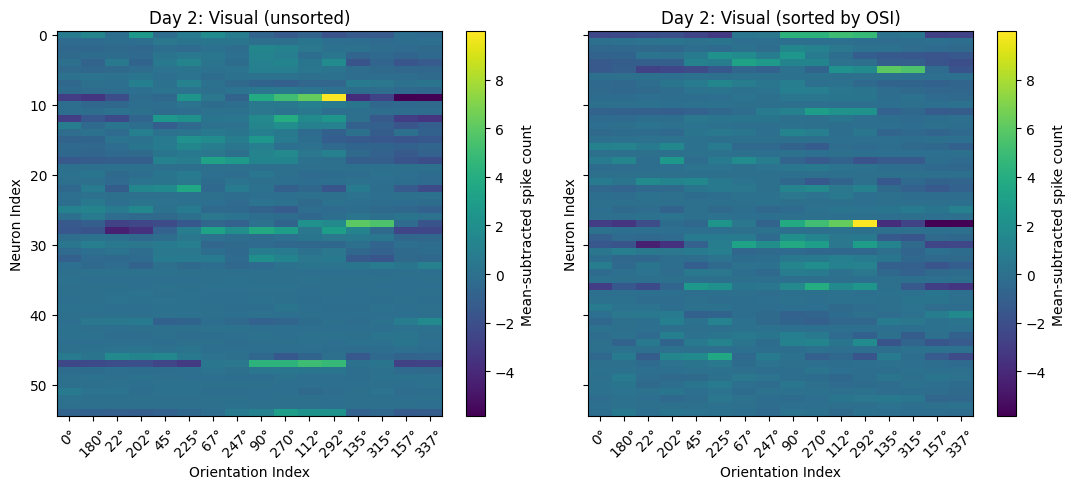

OSI range: 0.024 – 0.381  |  median: 0.104
Neuron order (high→low OSI): [47 45  2 15 18 27 36 16  5 48] ...


In [9]:
ori_order = [0, 8, 1, 9, 2, 10, 3, 11, 4, 12, 5, 13, 6, 14, 7, 15]

# Orientation selectivity index (OSI) via circular variance on doubled angles.
# OSI = |Σ_θ r(θ) exp(2i·θ)| / Σ_θ r(θ)
# Ranges [0, 1]: 0 = untuned, 1 = perfectly selective.
thetas = np.deg2rad(visual_orientation_degs2)  # (n_oris,)
r = avg_vis_responses_2.sum(axis=-1).T                           # (n_neurons, n_oris)
r_pos = np.clip(r, 0, None)                   # ensure non-negative before summing
complex_tuning = r_pos @ np.exp(2j * thetas)   # (n_neurons,)
osi = np.abs(complex_tuning) / (r_pos.sum(axis=1) + 1e-9)  # (n_neurons,)

neuron_order = np.argsort(osi)[::-1]           # descending OSI

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, order, label in [
    (axes[0], np.arange(avg_vis_responses_2.shape[1]), 'unsorted'),
    (axes[1], neuron_order,                        'sorted by OSI'),
]:
    xx = avg_vis_responses_2.sum(axis=-1)[ori_order][:, order]
    xx = xx - xx.mean(axis=0, keepdims=True)
    im = ax.imshow(xx.T, aspect='auto', cmap='viridis')
    ax.set_ylabel('Neuron Index')
    ax.set_xlabel('Orientation Index')
    ax.set_xticks(np.arange(len(visual_orientation_degs2)))
    ax.set_xticklabels([f'{int(o)}°' for o in visual_orientation_degs2[ori_order]], rotation=45)
    ax.set_title(f'Day 2: Visual ({label})')
    plt.colorbar(im, ax=ax, label='Mean-subtracted spike count')

plt.tight_layout()
plt.show()

print(f"OSI range: {osi.min():.3f} – {osi.max():.3f}  |  median: {np.median(osi):.3f}")
print(f"Neuron order (high→low OSI): {neuron_order[:10]} ...")


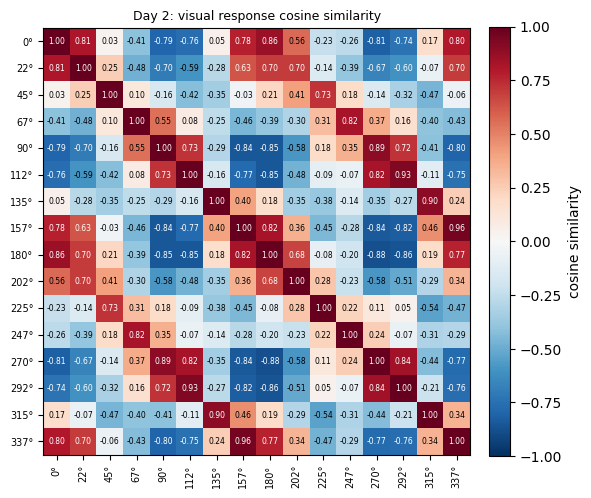

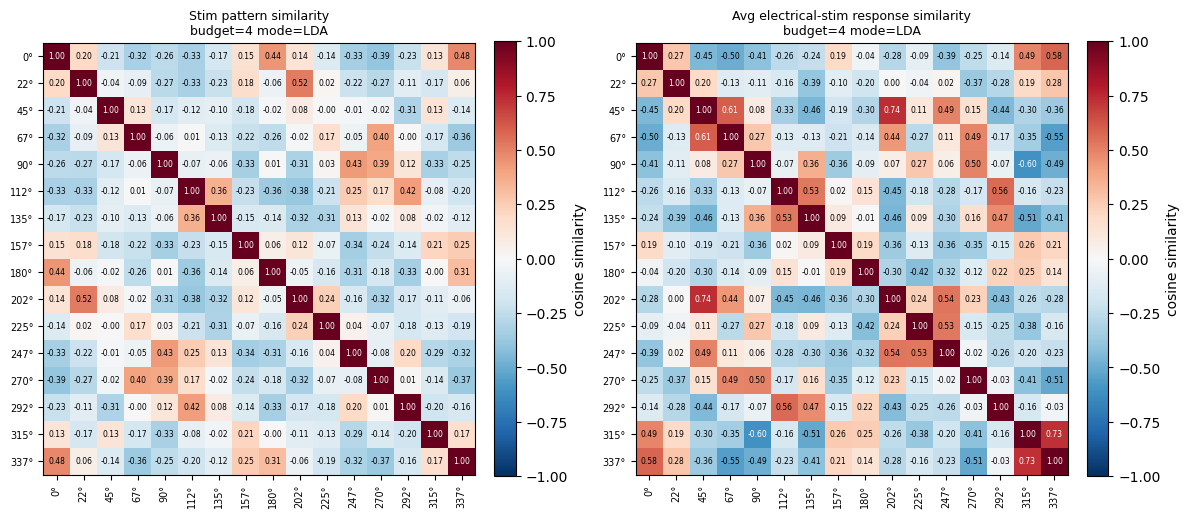

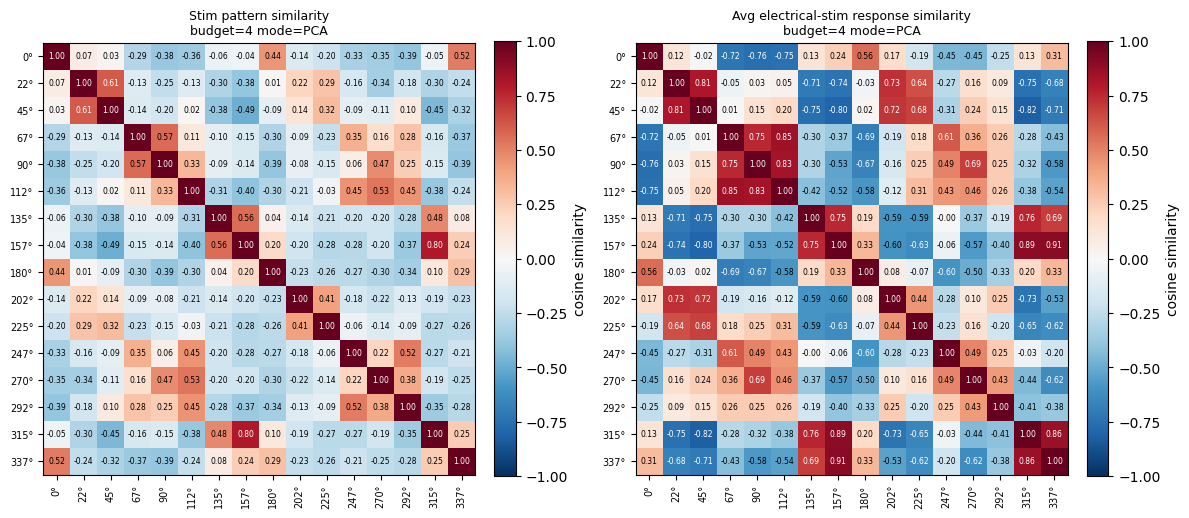

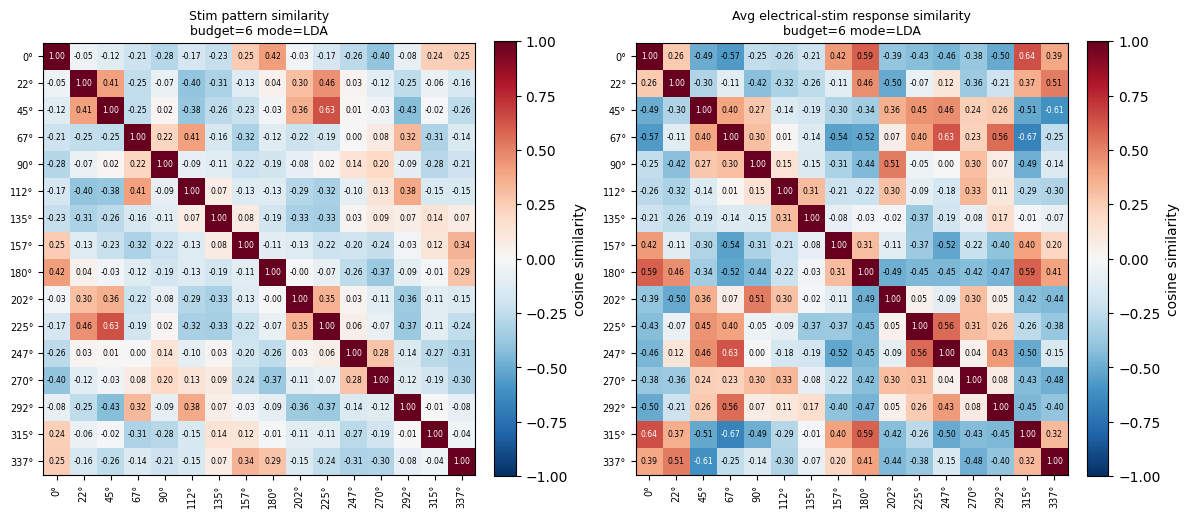

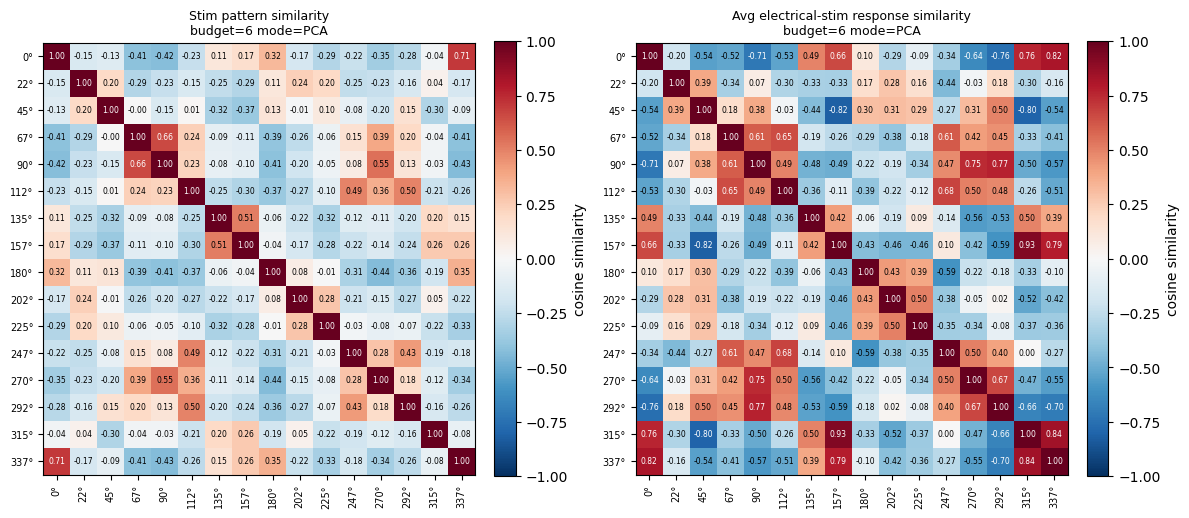

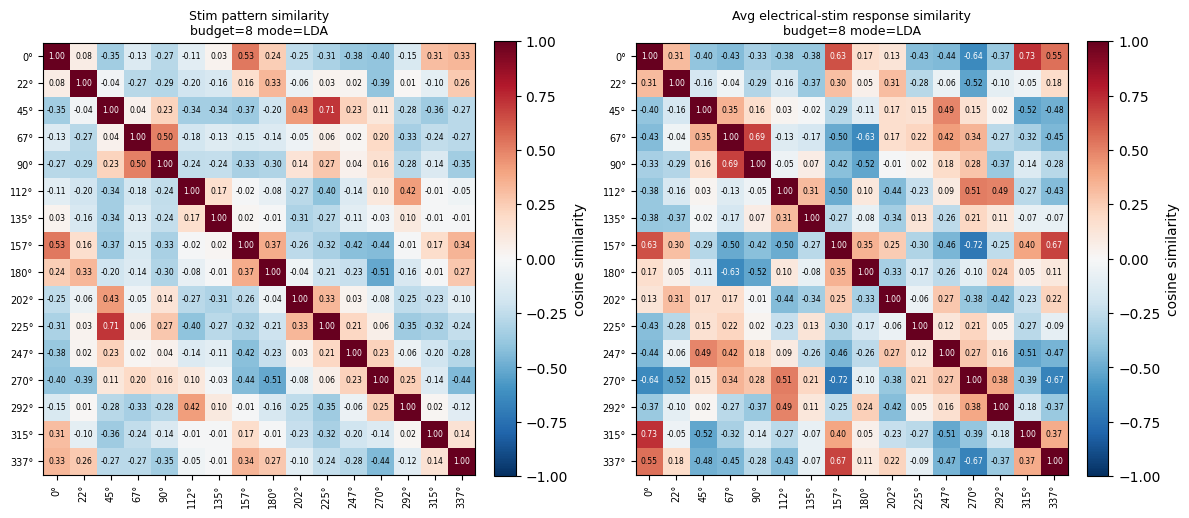

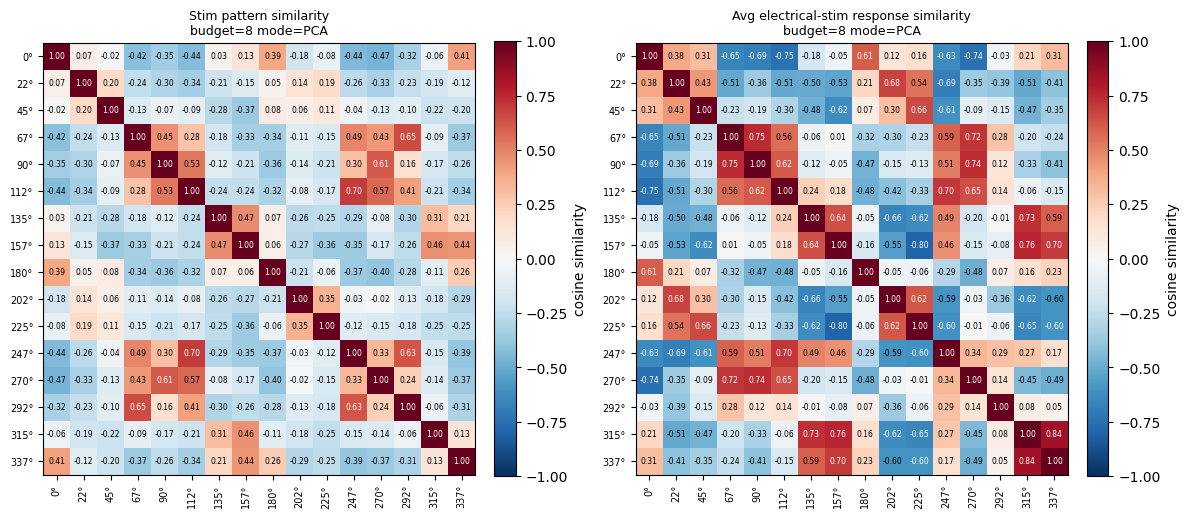

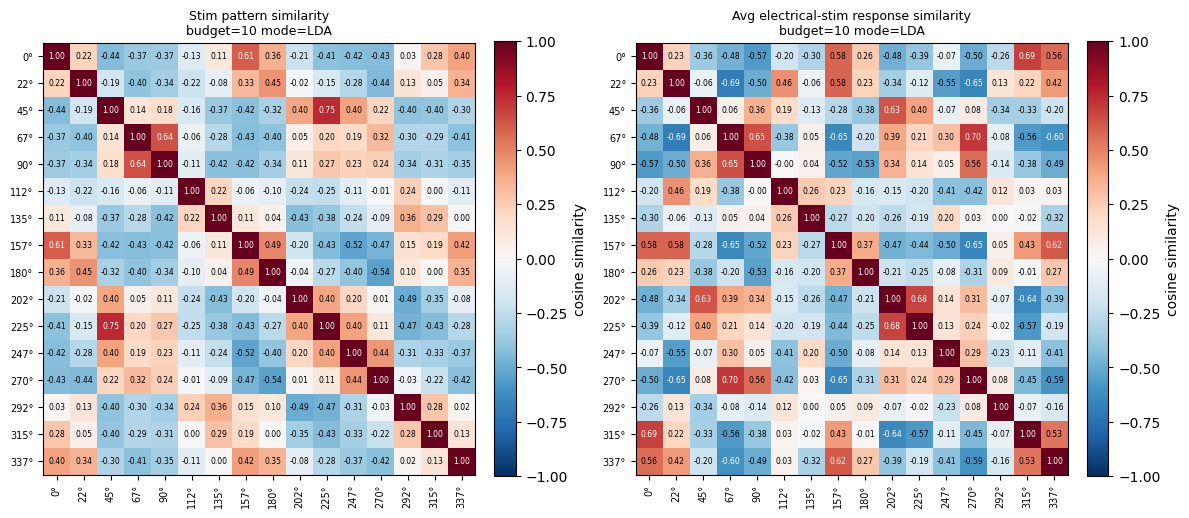

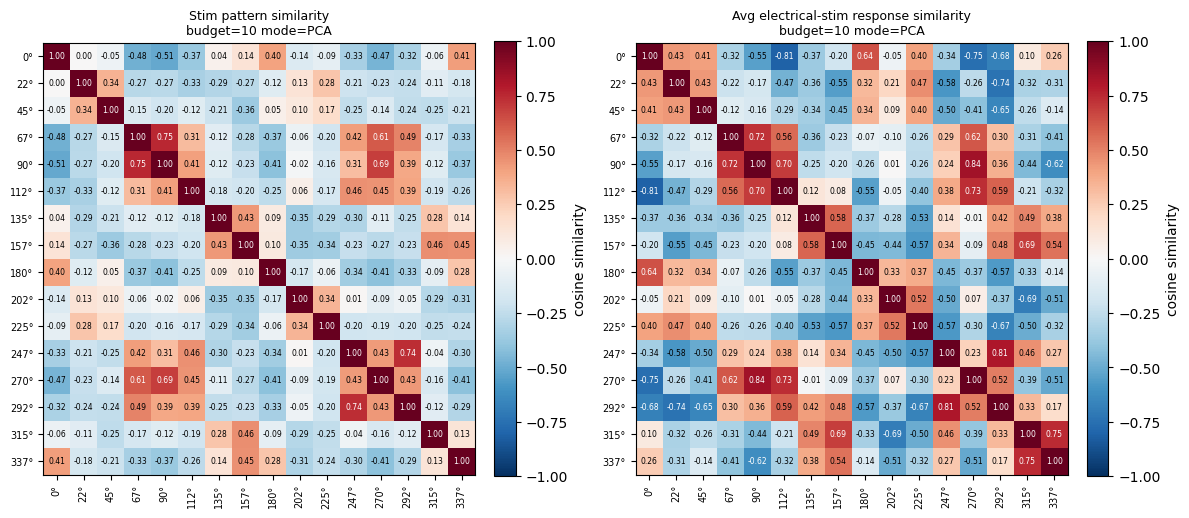

In [10]:
# ============================================================
# Pairwise cosine similarity across the 16 orientations, for:
#   1. Visual responses          (sum_responses_2, same for all budgets/modes)
#   2. Stim patterns delivered    (per budget/mode, from pattern_df_day2)
#   3. Average electrical-stim responses (stim_resp_mean, per budget/mode)
#
# Each matrix is (n_orient x n_orient), ordered by visual_orientation_degs2.
# ============================================================
from sklearn.preprocessing import normalize


def cosine_sim_matrix(X, center=True):
    """Row-wise cosine similarity matrix for X (n_rows, n_features)."""
    Xc = X - X.mean(axis=0, keepdims=True) if center else X
    Xn = normalize(Xc, norm='l2')
    return Xn @ Xn.T


def plot_sim_matrix(ax, sim, labels, title):
    n = len(labels)
    im = ax.imshow(sim, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([f'{int(o)}°' for o in labels], rotation=90, fontsize=7)
    ax.set_yticklabels([f'{int(o)}°' for o in labels], fontsize=7)
    ax.set_title(title, fontsize=9)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{sim[i, j]:.2f}', ha='center', va='center',
                    fontsize=5.5, color='white' if abs(sim[i, j]) > 0.6 else 'black')
    return im


# --- 1. Visual response similarity (orientation x neuron, summed over time) ---
sim_visual = cosine_sim_matrix(avg_vis_responses_2.sum(axis=-1))  # (n_orient, n_orient)

fig, ax = plt.subplots(figsize=(6, 5.5))
im = plot_sim_matrix(ax, sim_visual, visual_orientation_degs2,
                      'Day 2: visual response cosine similarity')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='cosine similarity')
plt.tight_layout()
plt.show()

# --- 2 & 3. Per (budget, mode): stim pattern + avg electrical response similarity ---
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df_day2['channel'].dropna().unique()))}
pattern_stims_day2 = build_pattern_stims_nominal(
    pattern_df_day2[pattern_df_day2['pattern_name'].isin(xref['pattern_name'])],
    channel_to_index, VIS_ORIENT_TIME)

for b_idx, budget in enumerate(budgets):
    for m_idx, mode_ in enumerate(modes):
        grp = (xref[(xref['source_budget'] == budget) & (xref['decomp_method'] == mode_)]
               .sort_values('target_orientation_deg'))
        stim_flat = np.stack([pattern_stims_day2[int(p)].ravel() for p in grp['pattern_name']], axis=0)
        sim_stim = cosine_sim_matrix(stim_flat)

        resp = stim_resp_avg_sum[b_idx, m_idx]  # (n_orient, n_neurons), already ordered by `oris`
        sim_resp = cosine_sim_matrix(resp)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
        im0 = plot_sim_matrix(axes[0], sim_stim, visual_orientation_degs2,
                               f'Stim pattern similarity\nbudget={budget} mode={mode_.upper()}')
        im1 = plot_sim_matrix(axes[1], sim_resp, visual_orientation_degs2,
                               f'Avg electrical-stim response similarity\nbudget={budget} mode={mode_.upper()}')
        plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='cosine similarity')
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='cosine similarity')
        plt.tight_layout()
        plt.savefig(f'data/icms_150_6_3_26/sim_matrices_budget_{budget}_mode_{mode_}.png', dpi=150)
        plt.show()


In [ ]:
# Electrical-stim response ring: fit PCA on the per-orientation average stim
# responses themselves (no CIS axis) and project them into that 2-D space, to
# see whether the e-stim responses trace their own orientation ring. Individual
# deliveries are overlaid as low-alpha points (projected through the same basis).
def per_trial_stim_responses(pattern_name):
    """Per-delivery total spike counts for one pattern, summed over the
    VIS_ORIENT_TIME window. Returns (n_deliveries, n_neurons)."""
    onsets = deliveries[deliveries['pattern_name'] == pattern_name]['pattern_flag_start_timestamp'].values
    rows = []
    for t0 in onsets:
        seg = spikes_df_day2[(spikes_df_day2['timestamp'] >= t0) &
                             (spikes_df_day2['timestamp'] <  t0 + TRAJ_WIN_LEN)]
        v = np.zeros(d2_n_neurons)
        if not seg.empty:
            for nid, c in seg.groupby('neuron_id').size().items():
                if nid in d2_neuron_to_idx:
                    v[d2_neuron_to_idx[nid]] = c
        rows.append(v)
    return np.array(rows).reshape(-1, d2_n_neurons)   # (n_deliveries, n_neurons)

for b in budgets:
    for m in modes:
        print(f'Budget {b} Mode {m}:')
        if m != "pca":
            continue
        stim_resp = stim_resp_avg_sum[budgets.index(b), modes.index(m)]  # (n_orient, n_neurons)
        proj, coords = build_projection(stim_resp, mode="pca", include_cis=False)

        # Per-delivery points for each orientation, projected through the same basis.
        grp = (xref[(xref['source_budget'] == b) & (xref['decomp_method'] == m)]
               .sort_values('target_orientation_deg'))   # same orientation order as `oris`
        trial_pts, trial_doubled = [], []
        for _, row in grp.iterrows():
            per_trial = per_trial_stim_responses(int(row['pattern_name']))
            if len(per_trial) == 0:
                continue
            trial_pts.append(per_trial @ proj)
            trial_doubled.extend([(float(row['target_orientation_deg']) * 2) % 360] * len(per_trial))
        trial_coords  = np.vstack(trial_pts) if trial_pts else None
        trial_doubled = np.array(trial_doubled) if trial_pts else None

        fig = plot_ring(coords, visual_orientation_degs2,
                        f'Average Electrical Stim Responses (Budget {b} Mode {m.upper()})',
                        ['PC1', 'PC2'],
                        trial_coords=trial_coords, trial_doubled=trial_doubled)
        fig.write_image(f'{day2_datadir}/stim_resp_pca_budget_{b}_mode_{m}.png', scale=2)
        fig.show()


Correlation matrix shape: (16, 16)


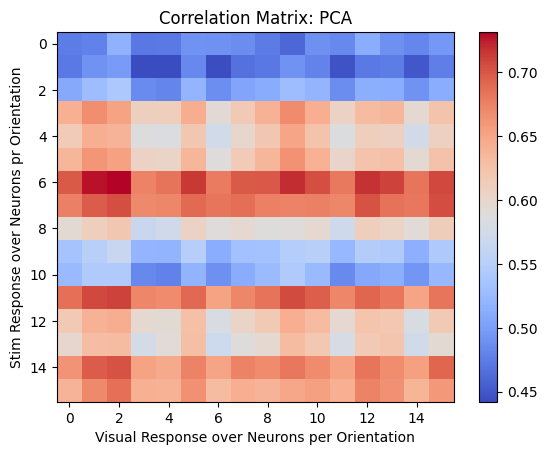

In [37]:
corr_budget = 4
corr_mode = analysis_mode

stim_resp = stim_resp_avg_sum[budgets.index(corr_budget), modes.index(corr_mode)]  # (n_orient, n_neurons)
visual_resp2 = avg_vis_responses_2.sum(axis=-1)  # (n_orient, n_neurons)
# Correlation of each stim response with each visual response, across neurons.
# result is a neurons x neurons matrix of how similarly the stim and visual responses are tuned across orientations for each neuron
full_matrix = np.corrcoef(stim_resp, visual_resp2)     # Result: (32, 32)
correlation_matrix = full_matrix[:16, 16:]             # Target block: (16, 16)
print (f'Correlation matrix shape: {correlation_matrix.shape}')
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xlabel('Visual Response over Neurons per Orientation')
plt.ylabel('Stim Response over Neurons pr Orientation')
plt.title(f'Correlation Matrix: {corr_mode.upper()}')
plt.show()

In [ ]:
# are there individual neurons whose tuning does not matter to visual response but who contribute to the PC1/PC2 a lot?
# For the PCA basis, we can look at the loadings of each neuron on PC1 and PC2, and see if those neurons have
# high or low correlation with the visual responses. This might reveal whether certain neurons are
# driving the PCA projection but are not strongly correlated with the visual responses.

# Rebuild the PCA basis from the SAME stim_resp used for the correlation below,
# so loadings and visual correlations describe the same (budget, mode) data.
# (Otherwise `proj` would be left over from the last iteration of the ring loop.)
proj_loadings, _ = build_projection(stim_resp, mode="pca", include_cis=False)  # (n_neurons, 2)

# Get the PCA loadings for each neuron on PC1 and PC2
pca_loadings = proj_loadings[:, :2]  # (n_neurons, 2)
# Get the correlation of each neuron with the visual responses across orientations
neuron_visual_corr = np.array([np.corrcoef(stim_resp[:, i], visual_resp2[:, i])[0, 1] for i in range(stim_resp.shape[1])])

# A neuron "drives the PC projection but isn't visually tuned" if it has a large
# |loading| on either PC but a near-zero correlation with the visual response.
# Define thresholds from the data: top-quartile loading, low |correlation|.
max_loading = np.abs(pca_loadings).max(axis=1)          # strongest of PC1/PC2 per neuron
load_thresh = np.nanpercentile(max_loading, 75)         # top-quartile loaders
corr_thresh = 0.2                                        # |corr| below this = "uncorrelated"
flagged = np.where((max_loading >= load_thresh) &
                   (np.abs(neuron_visual_corr) < corr_thresh))[0]

# Now we can plot the PCA loadings against the visual correlation for each neuron
plt.figure(figsize=(8, 6))
plt.scatter(np.abs(pca_loadings[:, 0]), neuron_visual_corr, label='PC1 Loading vs Visual Corr')
plt.scatter(np.abs(pca_loadings[:, 1]), neuron_visual_corr, label='PC2 Loading vs Visual Corr')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.axhspan(-corr_thresh, corr_thresh, color='gray', alpha=0.12,
            label=f'|corr| < {corr_thresh}')
plt.axvline(x=load_thresh, color='k', linestyle=':', alpha=0.5,
            label=f'top-quartile |loading| = {load_thresh:.3f}')

# Label every neuron at its strongest-PC point so each can be identified; flagged
# (high-loading / low-corr) neurons are emphasised in red and bold.
for i in range(pca_loadings.shape[0]):
    x = max_loading[i]                       # plot the label at the stronger PC loading
    y = neuron_visual_corr[i]
    is_flagged = i in flagged
    plt.annotate(str(i), (x, y),
                 textcoords='offset points', xytext=(3, 2),
                 fontsize=8 if is_flagged else 6,
                 color='red' if is_flagged else 'gray',
                 fontweight='bold' if is_flagged else 'normal',
                 zorder=5 if is_flagged else 3)

plt.xlabel('Abs(PCA Loading)')
plt.ylabel('Correlation with Visual Response')
plt.title(f'Neuron PC loading vs visual correlation '
          f'(budget={corr_budget}, mode={corr_mode.upper()})')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Report the flagged neurons: strong PC driver, weak visual tuning.
order = flagged[np.argsort(max_loading[flagged])[::-1]]   # strongest loaders first
print(f'High-loading / low-visual-correlation neurons '
      f'(|loading| >= {load_thresh:.3f}, |corr| < {corr_thresh}):')
print(f'{"neuron":>6} {"|PC1|":>7} {"|PC2|":>7} {"max|load|":>10} {"visual_corr":>12}')
for i in order:
    print(f'{i:>6} {abs(pca_loadings[i,0]):>7.3f} {abs(pca_loadings[i,1]):>7.3f} '
          f'{max_loading[i]:>10.3f} {neuron_visual_corr[i]:>12.3f}')
if len(order) == 0:
    print('  (none met both thresholds)')
